In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/applied machine learning/credit_data.csv")
data.head(10)

,Age,Income,LoanAmount,CreditScore,EmploymentYears,Default
0,59,32666,28664,803,11,0
1,49,58660,6636,691,20,0
2,35,23561,25080,434,0,0
3,63,46854,32728,494,25,0
4,28,84505,31736,700,25,0
5,41,72251,33673,332,0,0
6,59,42662,42505,759,14,0
7,39,28392,5854,769,1,1
8,43,50535,29548,674,29,0
9,31,98603,43623,321,21,1


Default
0    77
1    23
Name: count, dtype: int64


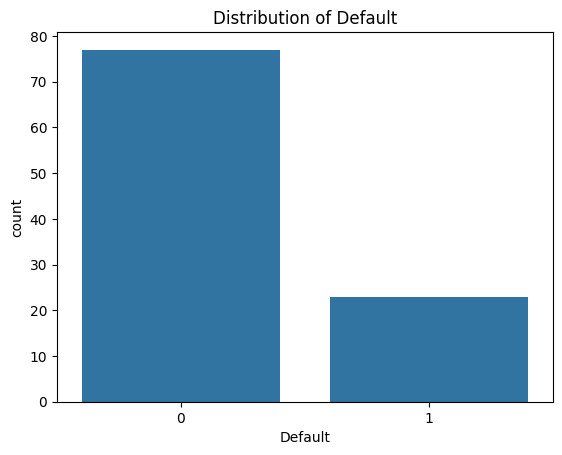

In [ ]:
print(data['Default'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Default', data=data)
plt.title("Distribution of Default")
plt.show()

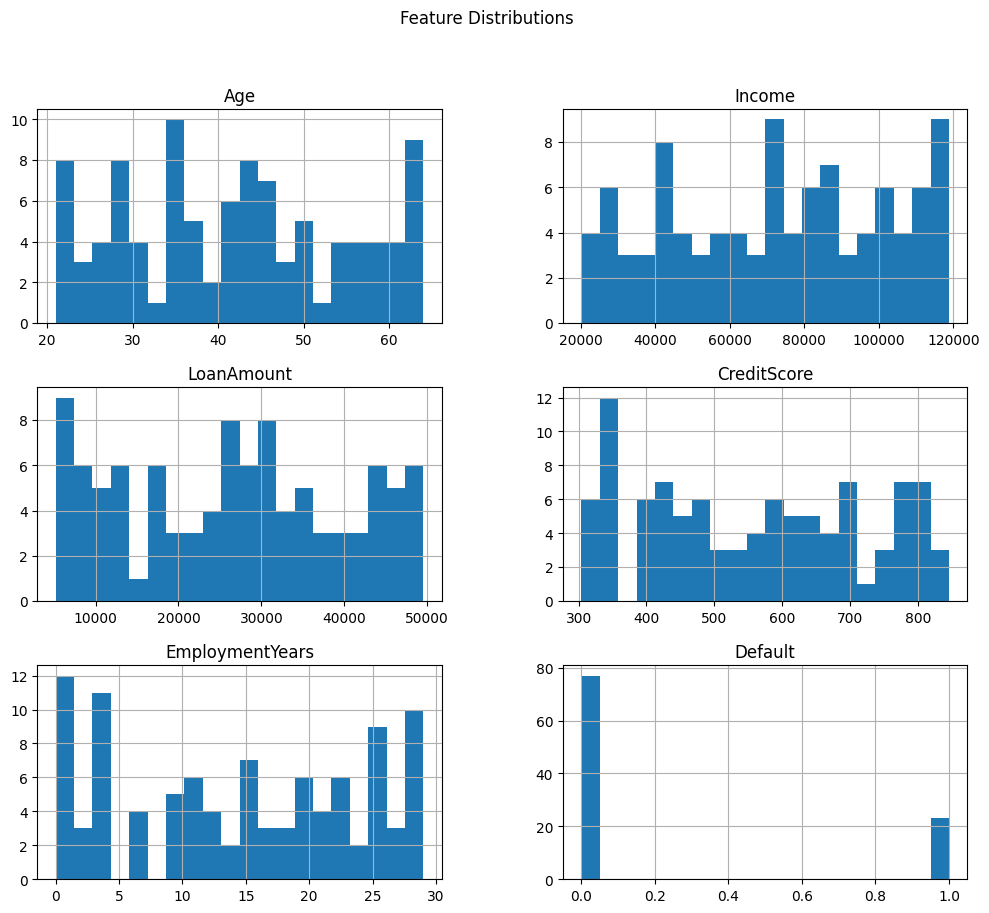

In [ ]:
data.hist(
    figsize=(12,10),
    bins=20
)

plt.suptitle("Feature Distributions")
plt.show()

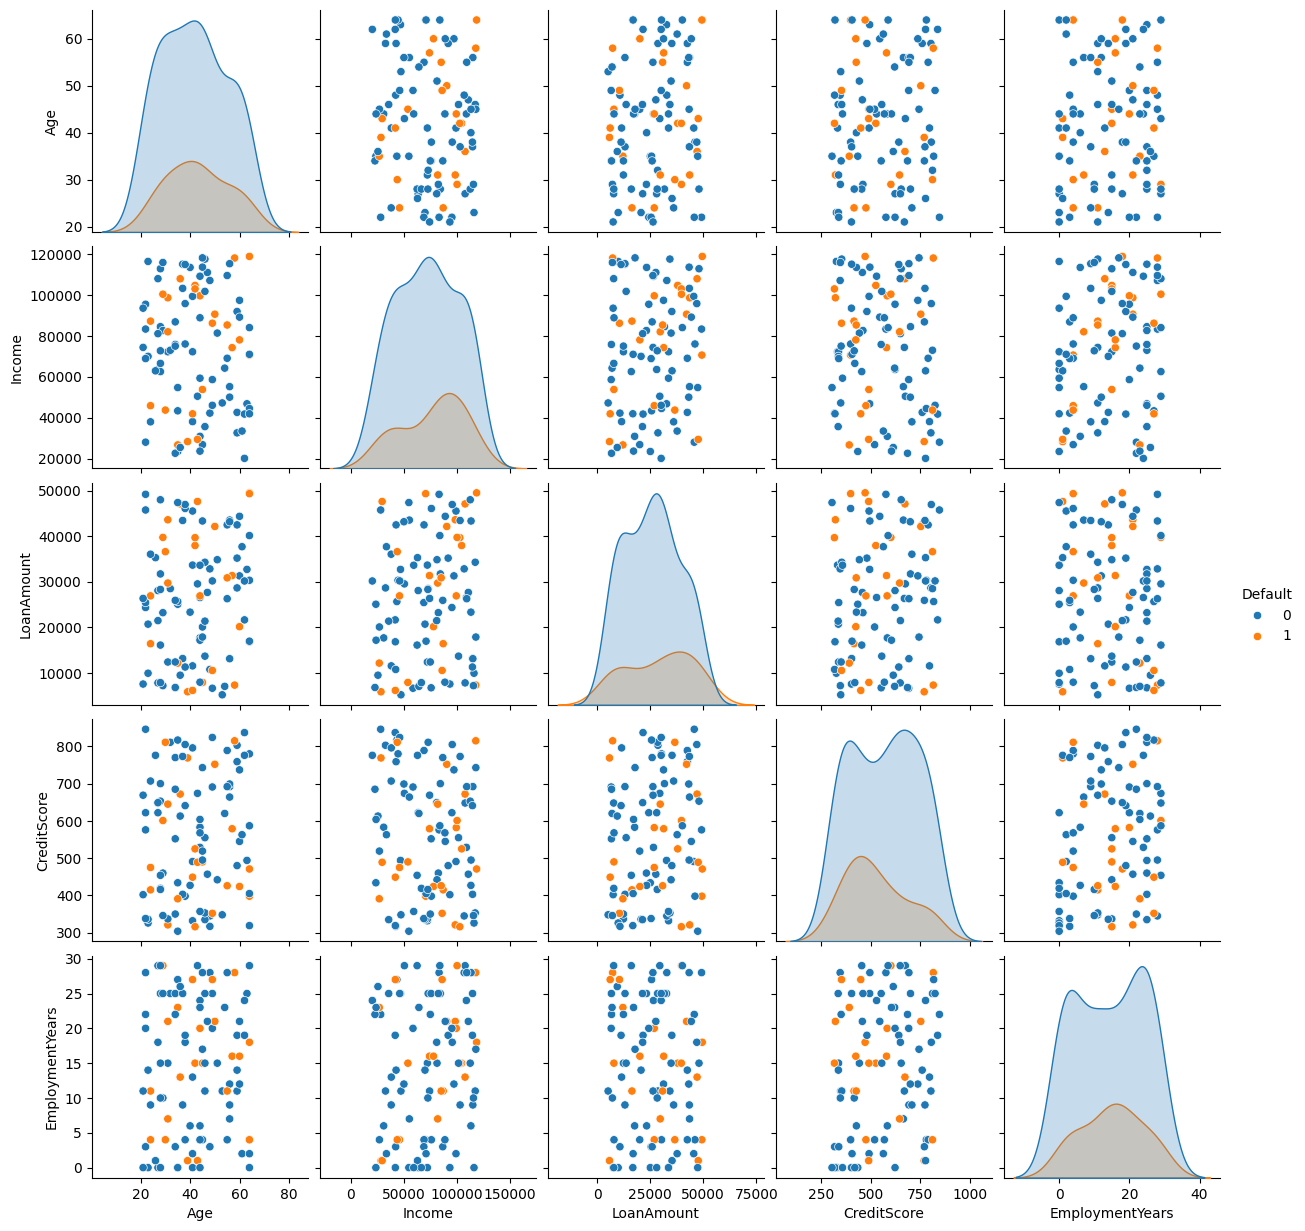

In [ ]:
# PAIRPLOT
# FEATURE-FEATURE PLOT
sns.pairplot(
    data,
    hue='Default'
)
# If data overlaps in pairplot → not necessarily non-linearly separable
plt.show()

In [ ]:
X = data.drop("Default", axis=1)
y = data["Default"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.65

Confusion Matrix:
[[13  2]
 [ 5  0]]
